# Task 0 [3 points]
For all tasks in this assignment, use the RecBole package (https://recbole.io/) and the Amazon
Beauty datasets. Get familiar with the package. For using the package for the entire pipeline (loading
and splitting the data, training the model, evaluation), you can obtain 3 points. These points may
be added to any of the following tasks.

# Task 1 [2 points]
1. Train and evaluate the SASRec model. Remember to split the data properly for the sequential
recommendations (last user interaction for testing, second last user interaction for validation).
Calculate the metrics (at least recall and nDCG) for k = 5, 10, 20 (note that you don’t need
to calculate the recommendations multiple times to do so).
2. Analyze the quality of recommendations for users with different sequence lengths:
- After performing the standard evaluation, divide the data based on the input sequence
length (e.g. 0 − 5, 5 − 10, 15 − 20, 20 − 30, 30+).
- Calculate how many sequences fall into each group.
- Calculate the metrics for each group.
- Visualize the results in a clear form. Describe your observations.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import torch

from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import get_model, get_trainer, init_seed

# np.float_ = np.float64
# np.complex_ = np.complex128
# np.unicode_ = np.str_

In [2]:
default_config_dict = {
    # dataset config : Sequential Recommendation
    "USER_ID_FIELD": "user_id",
    "ITEM_ID_FIELD": "item_id",
    "TIME_FIELD": "timestamp",
    "load_col": {"inter": ["user_id", "item_id", "timestamp"]},  # load user-item interactions with timestamp
    "ITEM_LIST_LENGTH_FIELD": "item_length",
    "LIST_SUFFIX": "_list",
    "MAX_ITEM_LIST_LENGTH": 35,  # maximum length of the item sequence for each user

    # model config
    "embedding_size": 64,
    "hidden_size": 128,
    "num_layers": 1,
    "dropout_prob": 0.3,
    "loss_type": 'CE',

    # Training and evaluation config
    "epochs": 10,
    "train_batch_size": 4096//4,
    "eval_batch_size": 4096//4,
    "train_neg_sample_args": None,
    "eval_args": {
        "group_by": "user",
        "order": "TO",
        "split": {"LS": "valid_and_test"},
        "mode": "full"
    },
    "metrics": ["Recall", "MRR", "NDCG", "Hit", "Precision"],
    "topk": [5, 10, 20],
    "valid_metric": "MRR@10"
}


In [3]:
config = Config(model="SASRec", dataset="amazon-beauty", config_dict=default_config_dict)
init_seed(config["seed"], config["reproducibility"])

dataset = create_dataset(config)
train_data, valid_data, test_data = data_preparation(config, dataset)

model = get_model(config["model"])(config, train_data._dataset).to(config["device"])
trainer = get_trainer(config["MODEL_TYPE"], config["model"])(config, model)

best_valid_score, best_valid_result = trainer.fit(train_data, valid_data, show_progress=True)
test_result = trainer.evaluate(test_data, load_best_model=True, show_progress=True)

print("Best validation score:", best_valid_score)
print("Best validation result:", best_valid_result)
print("Test result:", test_result)


D:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
D:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

Best validation score: 0.0207
Best validation result: OrderedDict({'recall@5': 0.0425, 'recall@10': 0.0612, 'recall@20': 0.0813, 'mrr@5': 0.0182, 'mrr@10': 0.0207, 'mrr@20': 0.0221, 'ndcg@5': 0.0242, 'ndcg@10': 0.0303, 'ndcg@20': 0.0353, 'hit@5': 0.0425, 'hit@10': 0.0612, 'hit@20': 0.0813, 'precision@5': 0.0085, 'precision@10': 0.0061, 'precision@20': 0.0041})
Test result: OrderedDict({'recall@5': 0.0387, 'recall@10': 0.0538, 'recall@20': 0.0698, 'mrr@5': 0.0169, 'mrr@10': 0.0189, 'mrr@20': 0.02, 'ndcg@5': 0.0223, 'ndcg@10': 0.0272, 'ndcg@20': 0.0312, 'hit@5': 0.0387, 'hit@10': 0.0538, 'hit@20': 0.0698, 'precision@5': 0.0077, 'precision@10': 0.0054, 'precision@20': 0.0035})


In [4]:
def evaluate_by_sequence_length(trainer, test_data, topk=(5, 10, 20)):
    """Evaluate full-sort sequential recommendations grouped by input item_length."""
    max_k = max(topk)
    rows = []   # results for each sequence (batch)

    # make sure the model is ready for full-sort evaluation
    trainer.model.eval()
    trainer.tot_item_num = test_data._dataset.item_num
    if getattr(trainer, "item_tensor", None) is None:
        trainer.item_tensor = test_data._dataset.get_item_feature().to(trainer.device)

    # dcg discounts are the same for every batch
    discounts = 1.0 / torch.log2(torch.arange(max_k, device=trainer.device, dtype=torch.float32) + 2.0)

    with torch.no_grad():
        for batched_data in test_data:
            # get scores for all items and keep only users with positives
            # interaction: the batch of interactions,
            # scores: the predicted scores for all items,
            # positive_u: indices of users with a true next item,
            # positive_i: the true next item for each user in positive_u
            interaction, scores, positive_u, positive_i = trainer._full_sort_batch_eval(batched_data)
            positive_u = torch.as_tensor(positive_u, device=trainer.device)
            positive_i = torch.as_tensor(positive_i, device=trainer.device)

            # check if the true next item is in top-k
            top_items = torch.topk(scores, k=max_k, dim=1).indices  # predicted top-k
            hits = top_items[positive_u].eq(positive_i.unsqueeze(1))
            item_lengths = interaction[trainer.config["ITEM_LIST_LENGTH_FIELD"]].to(trainer.device)[positive_u]

            batch = {"item_length": item_lengths.detach().cpu().numpy()}
            for k in topk:
                hit_at_k = hits[:, :k].any(dim=1).float()
                ndcg_at_k = (hits[:, :k].float() * discounts[:k]).max(dim=1).values
                batch[f"recall@{k}"] = hit_at_k.detach().cpu().numpy()
                batch[f"ndcg@{k}"] = ndcg_at_k.detach().cpu().numpy()

            rows.append(pd.DataFrame(batch))

    per_sequence = pd.concat(rows, ignore_index=True)

    # split sequences into length ranges for easier comparison
    bins = [0, 5, 10, 15, 20, 30, np.inf]
    labels = ["0-5", "6-10", "11-15", "16-20", "21-30", "31+"]
    per_sequence["length_group"] = pd.cut(
        per_sequence["item_length"], bins=bins, labels=labels, include_lowest=True, right=True
    )

    aggregations = {"item_length": "size"}
    for k in topk:
        aggregations[f"recall@{k}"] = "mean"
        aggregations[f"ndcg@{k}"] = "mean"

    # average metrics inside each length group
    by_length = (
        per_sequence.groupby("length_group", observed=False)
        .agg(aggregations)
        .rename(columns={"item_length": "n_sequences"})
        .reset_index()
    )
    return per_sequence, by_length


per_sequence_metrics, length_group_metrics = evaluate_by_sequence_length(trainer, test_data)
length_group_metrics


,length_group,n_sequences,recall@5,ndcg@5,recall@10,ndcg@10,recall@20,ndcg@20
0,0-5,120635,0.040884,0.023547,0.056509,0.028599,0.072276,0.032577
1,6-10,17785,0.026708,0.015352,0.037504,0.018830,0.052797,0.022699
2,11-15,4553,0.028333,0.016475,0.038436,0.019713,0.053152,0.023434
3,16-20,1735,0.028242,0.016230,0.047839,0.022616,0.076081,0.029827
4,21-30,1301,0.039201,0.023391,0.059185,0.029877,0.089931,0.037463
5,31+,986,0.053753,0.031849,0.084178,0.041742,0.113590,0.049407


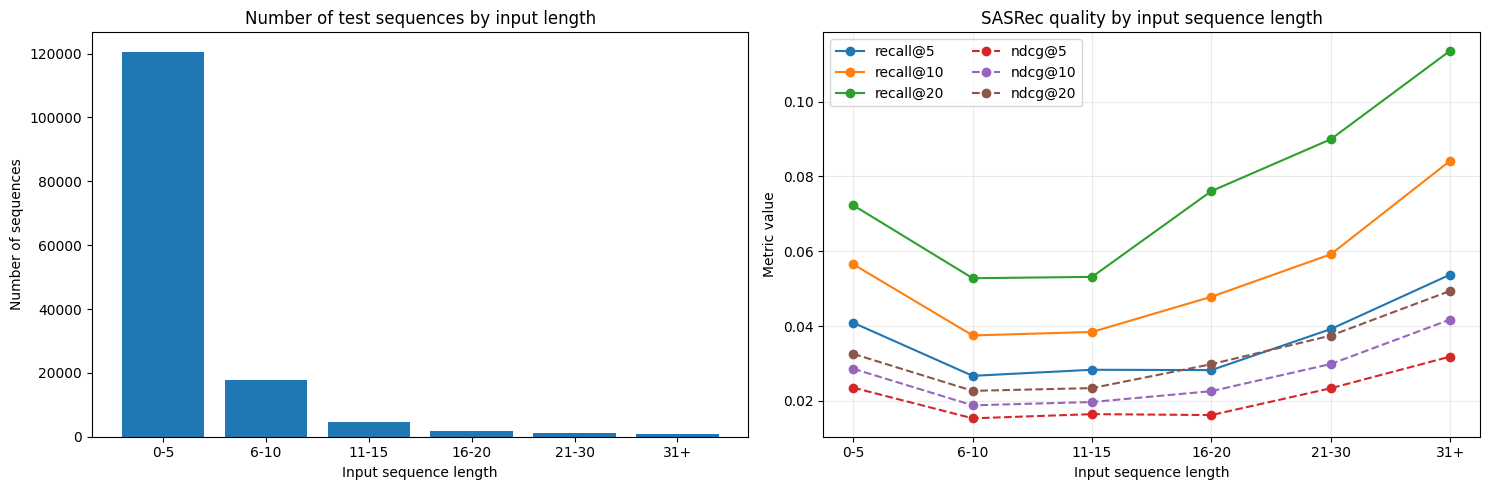

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(length_group_metrics["length_group"].astype(str), length_group_metrics["n_sequences"])
axes[0].set_title("Number of test sequences by input length")
axes[0].set_xlabel("Input sequence length")
axes[0].set_ylabel("Number of sequences")

for metric, linestyle in [("recall", "-"), ("ndcg", "--")]:
    for k in [5, 10, 20]:
        axes[1].plot(
            length_group_metrics["length_group"].astype(str),
            length_group_metrics[f"{metric}@{k}"],
            marker="o",
            linestyle=linestyle,
            label=f"{metric}@{k}",
        )

axes[1].set_title("SASRec quality by input sequence length")
axes[1].set_xlabel("Input sequence length")
axes[1].set_ylabel("Metric value")
axes[1].legend(ncol=2)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


Most test sequences are in the 0-5 length group.  
The best Recall@20 is for length group 31+    
The best NDCG@20 is for length group 31+    
Group 0-5 performs better than next one - probably because of the large number of sequences in this group


# Task 2 [2 points]
1. Train and evaluate the LightGCN model. Use a proper data split. Calculate the metrics (at least
recall and nDCG) for k = 5, 10, 20 (note that you don’t need to calculate the recommendations
multiple times to do so).
2. Analyze the popularity of items:
- Calculate the popularity of each item. Make a bar plot with ordered popularities (from
largest to smallest).
- Analyze the popularity of the items you have recommended: how popular are the items
you recommend, and how often items of different popularity are recommended.
- By doing this analysis, you can observe the Matthew effect for Recommender Systems.
Explain it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import torch

from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import get_model, get_trainer, init_seed

# np.float_ = np.float64
# np.complex_ = np.complex128
# np.unicode_ = np.str_

In [ ]:
lightgcn_config_dict = {
    "USER_ID_FIELD": "user_id",
    "ITEM_ID_FIELD": "item_id",
    "TIME_FIELD": "timestamp",
    "load_col": {"inter": ["user_id", "item_id", "timestamp"]},

    "user_inter_num_interval": "[3,inf)",
    "item_inter_num_interval": "[3,inf)",

    # LightGCN hyperparameters
    "embedding_size": 64,
    "n_layers": 2,
    "reg_weight": 1e-5,
    "require_pow": False,

    "epochs": 10,
    "train_batch_size": 4096,
    "eval_batch_size": 4096*2048,
    "train_neg_sample_args": {"distribution": "uniform", "sample_num": 1},

    # Temporal leave-one-out split
    "eval_args": {
        "group_by": "user",
        "order": "TO",
        "split": {"LS": "valid_and_test"},
        "mode": "full",
    },
    "metrics": ["Recall", "NDCG"],
    "topk": [5, 10, 20],
    "valid_metric": "NDCG@10",
    "metric_decimal_place": 4,
}

lightgcn_config = Config(model="LightGCN", dataset="amazon-beauty", config_dict=lightgcn_config_dict)
init_seed(lightgcn_config["seed"], lightgcn_config["reproducibility"])

lightgcn_dataset = create_dataset(lightgcn_config)
lightgcn_train_data, lightgcn_valid_data, lightgcn_test_data = data_preparation(
    lightgcn_config, lightgcn_dataset
)

lightgcn_model = get_model(lightgcn_config["model"])(
    lightgcn_config, lightgcn_train_data._dataset
).to(lightgcn_config["device"])
lightgcn_trainer = get_trainer(lightgcn_config["MODEL_TYPE"], lightgcn_config["model"])(
    lightgcn_config, lightgcn_model
)

lightgcn_best_valid_score, lightgcn_best_valid_result = lightgcn_trainer.fit(
    lightgcn_train_data, lightgcn_valid_data, show_progress=True
)
lightgcn_test_result = lightgcn_trainer.evaluate(
    lightgcn_test_data, load_best_model=True, show_progress=True
)

print("Best validation score:", lightgcn_best_valid_score)
print("Best validation result:", lightgcn_best_valid_result)
print("Test result:", lightgcn_test_result)


D:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
D:\SharedData\Documents\GitHub\UWr\Sem8\ADM\List6\.venv\Lib\site-packages\recbole\data\dataset\dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the inte

Best validation score: 0.0174
Best validation result: OrderedDict({'recall@5': 0.0212, 'recall@10': 0.0327, 'recall@20': 0.049, 'ndcg@5': 0.0137, 'ndcg@10': 0.0174, 'ndcg@20': 0.0215})
Test result: OrderedDict({'recall@5': 0.0124, 'recall@10': 0.021, 'recall@20': 0.0323, 'ndcg@5': 0.008, 'ndcg@10': 0.0108, 'ndcg@20': 0.0136})


In [8]:
def item_popularity_from_dataset(dataset, item_field):
    item_ids = dataset.inter_feat[item_field].detach().cpu().numpy()
    popularity = pd.Series(item_ids).value_counts().rename_axis("item_id").reset_index(name="popularity")
    popularity = popularity.sort_values("popularity", ascending=False).reset_index(drop=True)
    popularity["popularity_rank"] = np.arange(1, len(popularity) + 1)
    return popularity


item_popularity = item_popularity_from_dataset(
    lightgcn_train_data._dataset, lightgcn_config["ITEM_ID_FIELD"]
)
item_popularity.head(20)


,item_id,popularity,popularity_rank
0,27913,661,1
1,9554,604,2
2,695,531,3
3,25058,519,4
4,15427,512,5
5,10828,483,6
6,33047,446,7
7,14886,422,8
8,23896,405,9
9,30393,373,10


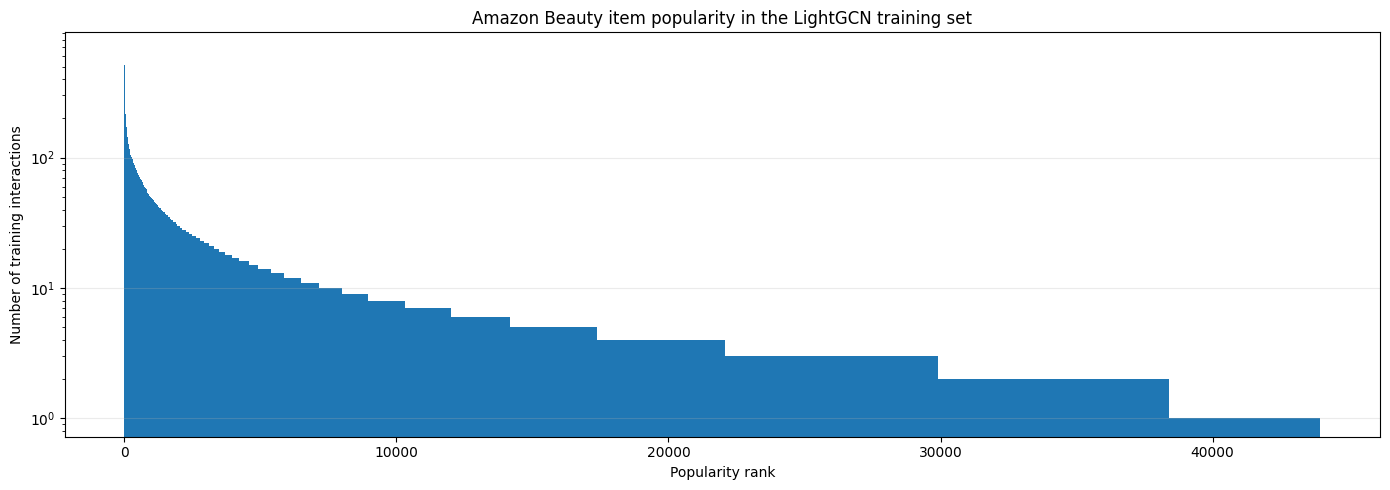

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(item_popularity["popularity_rank"], item_popularity["popularity"], width=1.0)
ax.set_title("Amazon Beauty item popularity in the LightGCN training set")
ax.set_xlabel("Popularity rank")
ax.set_ylabel("Number of training interactions")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


**Observations**: more popular items are dominating the interactions

In [10]:
def collect_full_sort_recommendations(trainer, eval_data, topk=20):
    trainer.model.eval()
    trainer.tot_item_num = eval_data._dataset.item_num
    if getattr(trainer, "item_tensor", None) is None:
        trainer.item_tensor = eval_data._dataset.get_item_feature().to(trainer.device)

    rows = []
    with torch.no_grad():
        for batched_data in eval_data:
            interaction, scores, positive_u, positive_i = trainer._full_sort_batch_eval(batched_data)
            positive_u = torch.as_tensor(positive_u, device=trainer.device)
            positive_i = torch.as_tensor(positive_i, device=trainer.device)

            recommended_items = torch.topk(scores, k=topk, dim=1).indices   # topk predicted items for each user
            users = interaction[trainer.config["USER_ID_FIELD"]].detach().cpu().numpy()
            recommended_items = recommended_items.detach().cpu().numpy()

            # convert results to DF
            for row_idx, user_id in enumerate(users):
                for rank, item_id in enumerate(recommended_items[row_idx], start=1):
                    rows.append({"user_id": user_id, "item_id": item_id, "rank": rank})

    return pd.DataFrame(rows)


# merge recommended items with their popularity
recommended_items = collect_full_sort_recommendations(lightgcn_trainer, lightgcn_test_data, topk=20)
recommended_item_popularity = recommended_items.merge(item_popularity, on="item_id", how="left")
recommended_item_popularity["popularity"] = recommended_item_popularity["popularity"].fillna(0)
recommended_item_popularity["popularity_rank"] = recommended_item_popularity["popularity_rank"].fillna(
    len(item_popularity) + 1
)

recommended_item_popularity.head(20)


,user_id,item_id,rank,popularity,popularity_rank
0,1,10828,1,483,6
1,1,9554,2,604,2
2,1,695,3,531,3
3,1,29728,4,291,22
4,1,27913,5,661,1
5,1,1631,6,253,29
6,1,20539,7,305,17
7,1,16440,8,255,28
8,1,29242,9,273,24
9,1,5119,10,297,19


In [11]:
# which items are recommended most often
recommended_frequency = (
    recommended_item_popularity.groupby("item_id")
    .agg(
        recommendation_count=("item_id", "size"),
        training_popularity=("popularity", "first"),
        popularity_rank=("popularity_rank", "first"),
    )
    .sort_values("recommendation_count", ascending=False)
    .reset_index()
)

# use linearly-spaced bins
max_popularity = int(recommended_item_popularity["popularity"].max())
popularity_bins = np.linspace(0, max_popularity, num=10).tolist()
popularity_labels = [
    f"{int(left) + 1}+" if np.isinf(right) else f"{int(left) + 1}-{int(right)}"
    for left, right in zip(popularity_bins[:-1], popularity_bins[1:])
]

recommended_item_popularity["popularity_group"] = pd.cut(
    recommended_item_popularity["popularity"],
    bins=popularity_bins,
    labels=popularity_labels,
    include_lowest=True,
    right=True,
)

# how many recommendations come from each popularity group and how they perform on average
recommendations_by_popularity = (
    recommended_item_popularity.groupby("popularity_group", observed=False)
    .agg(
        recommendation_count=("item_id", "size"),
        unique_items=("item_id", "nunique"),
        mean_rank=("rank", "mean"),
    )
    .reset_index()
)

# how much each popularity group contributes
recommendations_by_popularity["share_of_recommendations"] = (
    recommendations_by_popularity["recommendation_count"]
    / recommendations_by_popularity["recommendation_count"].sum()
)


display(recommended_frequency.head(20))
recommendations_by_popularity


,item_id,recommendation_count,training_popularity,popularity_rank
0,9554,58587,604,2
1,25058,57406,519,4
2,8203,52547,360,12
3,878,50426,340,14
4,23896,41933,405,9
5,518,41002,219,40
6,5119,40582,297,19
7,15427,39837,512,5
8,20539,35350,305,17
9,8620,35344,269,25


,popularity_group,recommendation_count,unique_items,mean_rank,share_of_recommendations
0,1-73,377008,3207,11.031044,0.171798
1,74-146,218733,242,13.930632,0.099674
2,147-220,609256,73,12.921869,0.277631
3,221-293,366022,18,10.453858,0.166792
4,294-367,293366,10,7.753209,0.133684
5,368-440,66435,3,6.671559,0.030274
6,441-514,90675,3,7.086330,0.041320
7,515-587,89804,2,5.264454,0.040923
8,588-661,83181,2,3.654873,0.037905


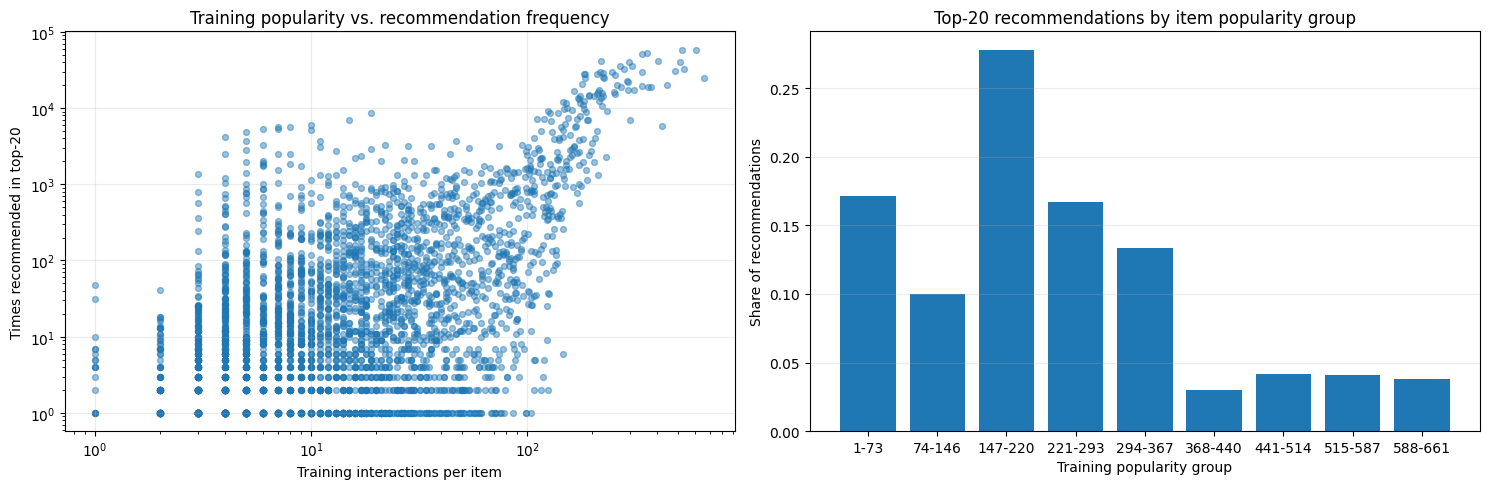

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(
    recommended_frequency["training_popularity"],
    recommended_frequency["recommendation_count"],
    alpha=0.45,
    s=18,
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Training popularity vs. recommendation frequency")
axes[0].set_xlabel("Training interactions per item")
axes[0].set_ylabel("Times recommended in top-20")
axes[0].grid(alpha=0.25)

axes[1].bar(
    recommendations_by_popularity["popularity_group"].astype(str),
    recommendations_by_popularity["share_of_recommendations"],
)
axes[1].set_title("Top-20 recommendations by item popularity group")
axes[1].set_xlabel("Training popularity group")
axes[1].set_ylabel("Share of recommendations")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


**Observations**: 
- items with higher number of interactions (popularity) are more often recommended by the model in top-20 recommendations
- there is visible popularity gap between items that are recommended often and items that are recommended rarely 

**Matthew effect** - "the rich get richer and the poor get poorer" - the popular items get more popular because they are recommended more often, leading to a feedback loop where popular items become even more popular while less popular items struggle to gain visibility.